# Qadence Kickstart: Quantum Kernels, Neural Nets & Generative Models

**Lessons 06 + 07 + 08 of the QML study guide.**

This is where the guide *converges on the quantum machine*. Three threads come together:

1. **Lesson 06 — Quantum kernels.** Simulate a tiny quantum feature map on a laptop, compute a quantum kernel
   as a squared state overlap `|⟨ψ(x)|ψ(x′)⟩|²`, feed it into the **same** KRR/SVM from Lesson 03, and watch
   **exponential concentration** appear with our own eyes. This is the heart of Pasqal's **QEK**.
2. **Lesson 07 — Neural networks.** Build a real multi-layer classifier; see the structure a *variational
   quantum circuit* mimics layer-for-layer.
3. **Lesson 08 — Generative models.** Distributions, sampling, NLL/KL/MMD — the scaffolding for **Born
   machines**, where measurement *is* sampling.

> **Enhancements in this notebook** (beyond the study-guide text): a visualization of the quantum feature map
> as a distribution over basis states; a 2-D concentration landscape over (encoding scale, qubit count); a
> correction to the "bandwidth sweet-spot" exercise (maximizing the *mean* overlap is a trap — you want maximal
> *informativeness*); a **data-dependent ZZ/Ising coupling** (closer to Rydberg physics than a fixed CZ); full
> decision-region plots for the classifier; and a categorical **Born-machine simulation**.

**Prereqs:** Lessons 02–03 (kernels, KRR/SVM), Lesson 05 (concentration ↔ barren plateaus), Lesson 01 (autograd).


## Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.svm import SVC
from sklearn.datasets import make_circles

torch.manual_seed(20000)
print("setup ready")

setup ready


---
# Lesson 06 — From Classical Kernels to Quantum Kernels

## 1. A quantum feature map, simulated on a laptop

No quantum hardware needed: a state on `n` qubits is just a complex vector of length `2ⁿ`. We encode a scalar
`x` by rotating each qubit (a different frequency per qubit) and adding a data-dependent phase, then take the
tensor product. The amplitudes are a **nonlinear feature map** of `x` — and `torch.kron` is what makes that
feature space grow *exponentially* (`2ⁿ`) with qubit count.

That exponential lift is the source of both quantum kernels' *promise* and their concentration *peril*.

**Enhancement:** we also include a `entangle` switch implementing a **data-dependent ZZ (Ising) coupling**
between neighbouring qubits — much closer to the physics of a Rydberg array than a fixed gate, and (unlike a
data-independent gate) it actually changes the kernel.

state length: 16 (= 2^4)   norm: 1.0


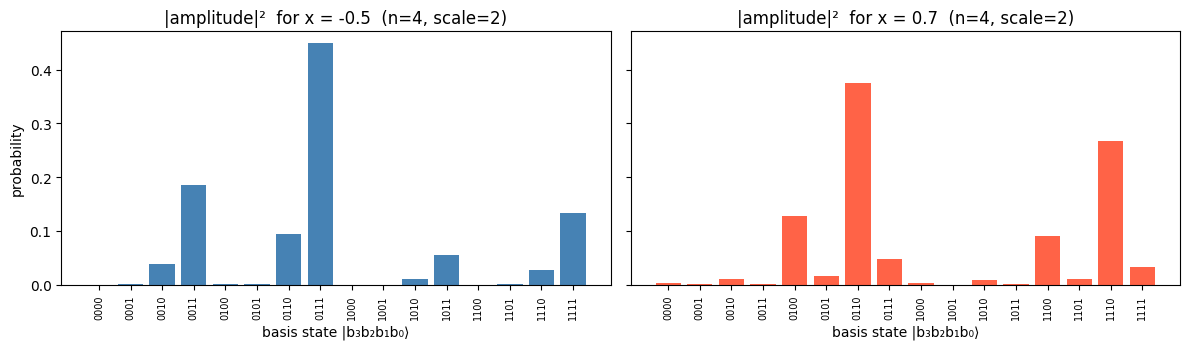

Different x -> different distribution over basis states. THAT is the feature map.


In [2]:
def single_qubit_state(angle):
    # |psi> = cos(a/2)|0> + sin(a/2)|1>
    a = torch.as_tensor(angle, dtype=torch.float)
    return torch.stack([torch.cos(a / 2), torch.sin(a / 2)]).to(torch.cfloat)

def _zz_chain(psi, n, theta):
    """Apply a data-dependent diagonal ZZ coupling exp(i*theta*Z_q Z_{q+1}) along a chain
    (the Ising/Rydberg-style interaction). Diagonal, so it acts as a phase per basis state."""
    idx = torch.arange(len(psi)); phase = torch.zeros(len(psi))
    for q in range(n - 1):
        zq  = 1 - 2 * ((idx >> (n - 1 - q)) & 1).float()          # +1 if bit is 0, -1 if 1
        zq1 = 1 - 2 * ((idx >> (n - 1 - (q + 1))) & 1).float()
        phase = phase + theta * (zq * zq1)
    return psi * torch.exp(1j * phase)

def feature_state(x, n_qubits=4, scale=1.0, entangle=False):
    """Tensor-product encoding of scalar x into a 2^n-dimensional quantum state."""
    psi = torch.tensor([1.0 + 0j])
    for q in range(n_qubits):
        qubit = single_qubit_state(scale * x * (q + 1))           # different frequency per qubit
        phase = torch.exp(1j * torch.tensor(scale * x))           # data-dependent phase on |1>
        qubit = qubit * torch.stack([torch.tensor(1.0 + 0j), phase])
        psi = torch.kron(psi, qubit)                              # tensor product -> length doubles
    if entangle:
        psi = _zz_chain(psi, n_qubits, scale * x)
    return psi / psi.norm()

s = feature_state(0.5, n_qubits=4)
print("state length:", s.shape[0], "(= 2^4)   norm:", round(s.norm().item(), 4))

# visualize the feature map as a distribution over the 2^n basis states (Born rule)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
basis = [format(i, '04b') for i in range(16)]
for ax, xv, col in [(axes[0], -0.5, 'steelblue'), (axes[1], 0.7, 'tomato')]:
    probs = feature_state(xv, 4, scale=2.0).abs() ** 2
    ax.bar(range(16), probs.numpy(), color=col)
    ax.set_xticks(range(16)); ax.set_xticklabels(basis, rotation=90, fontsize=7)
    ax.set_title(f'|amplitude|²  for x = {xv}  (n=4, scale=2)')
    ax.set_xlabel('basis state |b₃b₂b₁b₀⟩')
axes[0].set_ylabel('probability')
plt.tight_layout(); plt.show()
print("Different x -> different distribution over basis states. THAT is the feature map.")

## 2. The quantum kernel = squared state overlap

The quantum kernel is the **fidelity** between two feature states:

$$k(x, x') = |\langle \psi(x) | \psi(x') \rangle|^2$$

It is a valid kernel — **symmetric**, **unit diagonal** (a state has fidelity 1 with itself), and **PSD** — so
it drops straight into the Lesson 03 machinery.

symmetric: True | diag ~ 1: True | PSD: True


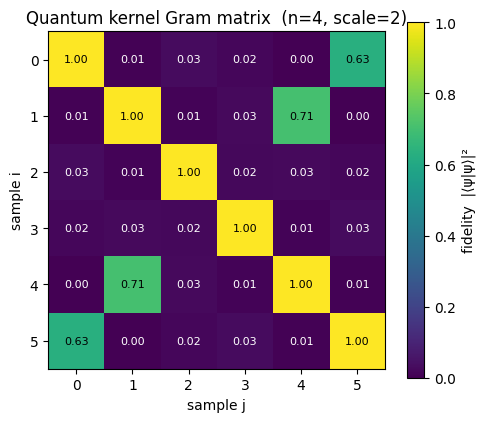

In [3]:
def quantum_kernel_matrix(xs, n_qubits=4, scale=1.0, entangle=False):
    states = [feature_state(float(x), n_qubits, scale, entangle) for x in xs]
    n = len(states); K = torch.zeros(n, n)
    for i in range(n):
        for j in range(n):
            overlap = torch.vdot(states[i], states[j])        # <psi_i | psi_j>
            K[i, j] = (overlap.conj() * overlap).real         # |<.|.>|^2  (fidelity)
    return K

xs = torch.linspace(-1, 1, 6)
K = quantum_kernel_matrix(xs, n_qubits=4, scale=2.0)
print("symmetric:", torch.allclose(K, K.T),
      "| diag ~ 1:", torch.allclose(torch.diag(K), torch.ones(6)),
      "| PSD:", torch.linalg.eigvalsh(K).min().item() > -1e-5)

plt.figure(figsize=(5, 4.3))
plt.imshow(K, cmap='viridis', vmin=0, vmax=1); plt.colorbar(label='fidelity  |⟨ψ|ψ⟩|²')
for i in range(6):
    for j in range(6):
        plt.text(j, i, f'{K[i,j]:.2f}', ha='center', va='center',
                 color='white' if K[i,j] < 0.6 else 'black', fontsize=8)
plt.title('Quantum kernel Gram matrix  (n=4, scale=2)')
plt.xlabel('sample j'); plt.ylabel('sample i')
plt.tight_layout(); plt.show()

## 3. Quantum kernel → the *same* KRR, unchanged

We reuse Lesson 03's kernel ridge regression verbatim — only `K` now comes from quantum states. On Pasqal
hardware `K` would come from a Rydberg processor instead of `torch.kron`; the learning code would not change a
single line.

quantum-kernel KRR train MSE: 0.0006


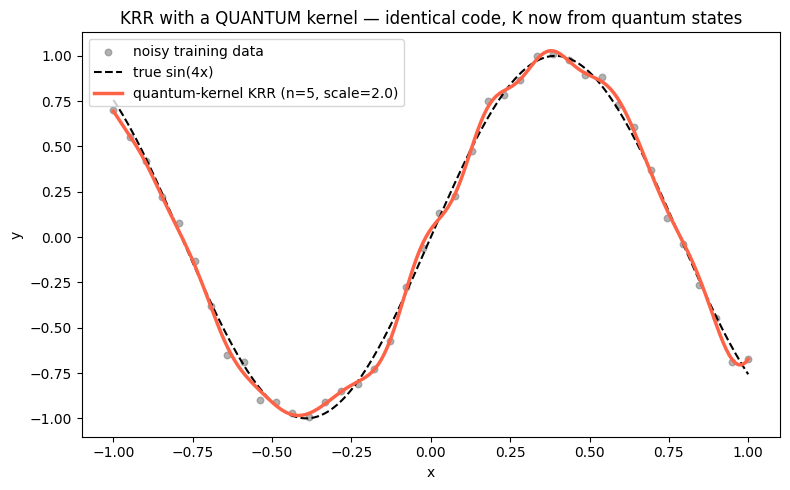

In [4]:
torch.manual_seed(0)
xtr = torch.linspace(-1, 1, 40)
ytr = torch.sin(4 * xtr) + 0.05 * torch.randn(40)
xte = torch.linspace(-1, 1, 200)

n_qubits, scale, lam = 5, 2.0, 1e-3
K = quantum_kernel_matrix(xtr, n_qubits, scale)
alpha = torch.linalg.solve(K + lam * torch.eye(len(xtr)), ytr)

# predict on a dense grid: kernel of each test point against the train points
states_tr = [feature_state(float(x), n_qubits, scale) for x in xtr]
states_te = [feature_state(float(x), n_qubits, scale) for x in xte]
K_te = torch.zeros(len(xte), len(xtr))
for i in range(len(xte)):
    for j in range(len(xtr)):
        ov = torch.vdot(states_te[i], states_tr[j]); K_te[i, j] = (ov.conj() * ov).real
y_pred = K_te @ alpha
print(f"quantum-kernel KRR train MSE: {((K @ alpha) - ytr).pow(2).mean().item():.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(xtr, ytr, s=22, c='gray', alpha=0.6, label='noisy training data')
plt.plot(xte, torch.sin(4 * xte), 'k--', lw=1.5, label='true sin(4x)')
plt.plot(xte, y_pred, 'tomato', lw=2.5, label=f'quantum-kernel KRR (n={n_qubits}, scale={scale})')
plt.title('KRR with a QUANTUM kernel — identical code, K now from quantum states')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Exponential concentration, observed

Scale up the qubit count and a poorly chosen feature map makes every pair of distinct points look orthogonal:
the off-diagonal kernel values crash toward zero, the Gram matrix → identity, and there is **no learnable
signal left**. This is the *quantum face* of Lesson 05's vanishing gradients — and a 2025 result proves the two
are formally equivalent.

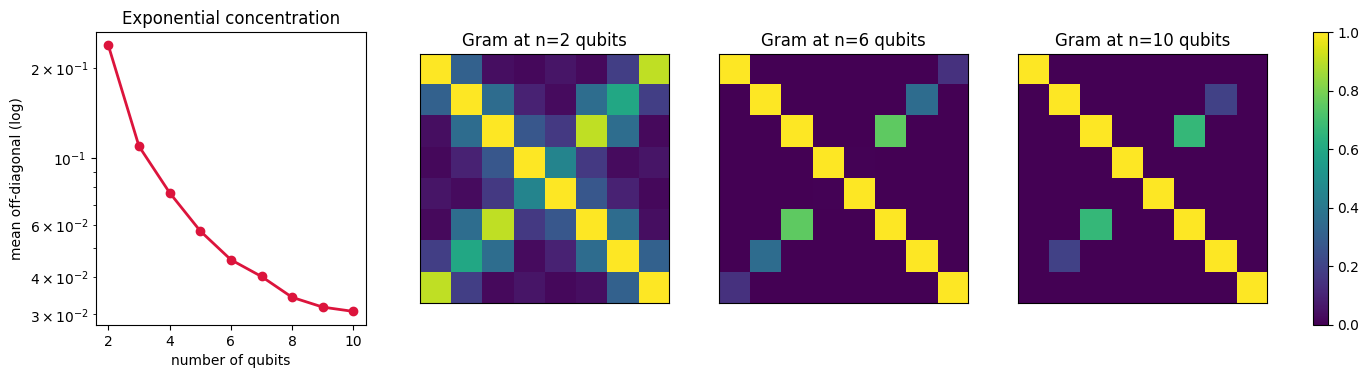

As n grows the Gram matrix drifts toward the IDENTITY -> distinct inputs become indistinguishable.


In [5]:
xs = torch.linspace(-1, 1, 8)
off_mask = ~torch.eye(8, dtype=bool)
n_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
mean_off = [quantum_kernel_matrix(xs, n, scale=3.0)[off_mask].mean().item() for n in n_list]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
axes[0].semilogy(n_list, mean_off, 'o-', color='crimson', lw=2)
axes[0].set_xlabel('number of qubits'); axes[0].set_ylabel('mean off-diagonal (log)')
axes[0].set_title('Exponential concentration')
for ax, n in zip(axes[1:], [2, 6, 10]):
    im = ax.imshow(quantum_kernel_matrix(xs, n, 3.0), cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'Gram at n={n} qubits'); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes[1:], fraction=0.025)
plt.show()
print("As n grows the Gram matrix drifts toward the IDENTITY -> distinct inputs become indistinguishable.")

**Enhancement — the full landscape.** Concentration is governed by *two* knobs together: the encoding
`scale` (bandwidth) and the qubit count. Mapping the mean off-diagonal over both shows the safe region (bright)
shrinking as qubits grow, and how a larger `scale` pushes you into the concentrated (dark) corner faster.

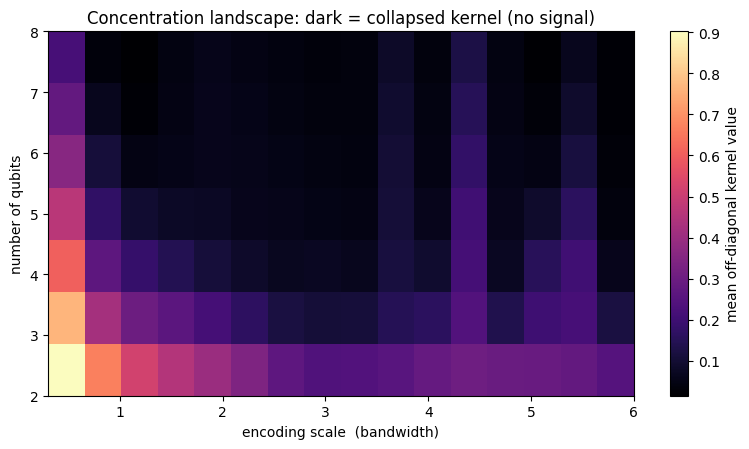

In [6]:
nq_list = [2, 3, 4, 5, 6, 7, 8]
scale_list = torch.linspace(0.3, 6.0, 16)
heat = np.array([[quantum_kernel_matrix(xs, nq, sc.item())[off_mask].mean().item()
                  for sc in scale_list] for nq in nq_list])

plt.figure(figsize=(8, 4.6))
im = plt.imshow(heat, aspect='auto', origin='lower', cmap='magma',
                extent=[scale_list[0], scale_list[-1], nq_list[0], nq_list[-1]])
plt.colorbar(im, label='mean off-diagonal kernel value')
plt.xlabel('encoding scale  (bandwidth)'); plt.ylabel('number of qubits')
plt.title('Concentration landscape: dark = collapsed kernel (no signal)')
plt.tight_layout(); plt.show()

## 5. Mitigations — and a correction to the "bandwidth sweet-spot"

The fix, as in Lesson 05, is **structure**. The first and cheapest lever is the **encoding scale** — the
quantum analogue of the RBF `σ`.

> ⚠️ **A subtlety the exercise glosses over.** "Maximize the mean off-diagonal kernel value" is a *trap*: the
> mean is maximized as `scale → 0`, where every state ≈ `|0…0⟩` and the kernel is the trivial all-ones matrix —
> useless. A *good* kernel is not one where points look maximally similar, it's one that is **informative**: it
> must *spread* similarities across the pairs. A better target is the **variance** of the off-diagonal entries
> (or, honestly, downstream task error). The two curves below disagree on purpose.

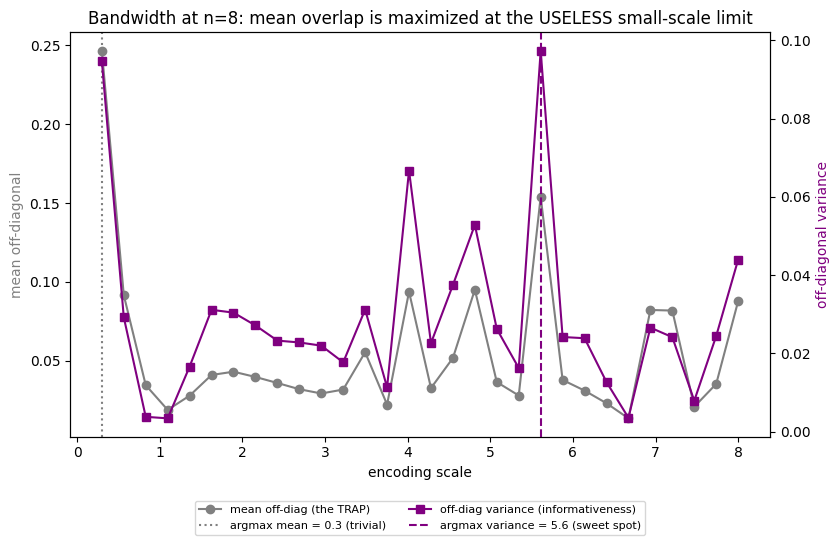

max mean -> scale 0.30 (trivial all-ones)   |   max informativeness -> scale 5.61


In [7]:
xs = torch.linspace(-1, 1, 10)
off_mask = ~torch.eye(10, dtype=bool)
scales = torch.linspace(0.3, 8.0, 30)
mean_off = [quantum_kernel_matrix(xs, 8, s.item())[off_mask].mean().item() for s in scales]
var_off  = [quantum_kernel_matrix(xs, 8, s.item())[off_mask].var().item()  for s in scales]

best_mean = scales[int(np.argmax(mean_off))].item()
best_var  = scales[int(np.argmax(var_off))].item()

fig, ax1 = plt.subplots(figsize=(8.5, 5))
ax1.plot(scales, mean_off, 'o-', color='gray', label='mean off-diag (the TRAP)')
ax1.axvline(best_mean, color='gray', ls=':', label=f'argmax mean = {best_mean:.1f} (trivial)')
ax1.set_xlabel('encoding scale'); ax1.set_ylabel('mean off-diagonal', color='gray')
ax2 = ax1.twinx()
ax2.plot(scales, var_off, 's-', color='purple', label='off-diag variance (informativeness)')
ax2.axvline(best_var, color='purple', ls='--', label=f'argmax variance = {best_var:.1f} (sweet spot)')
ax2.set_ylabel('off-diagonal variance', color='purple')
ax1.set_title('Bandwidth at n=8: mean overlap is maximized at the USELESS small-scale limit')
fig.legend(loc='upper center', fontsize=8, ncol=2, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(); plt.show()
print(f"max mean -> scale {best_mean:.2f} (trivial all-ones)   |   max informativeness -> scale {best_var:.2f}")

**Enhancement — does entanglement help or hurt? (exercise 3).** We compare the product encoding against
the **data-dependent ZZ coupling**. Adding interaction here actually *increases* concentration (the states
become more orthogonal faster) — a concrete reminder that more expressive ≠ more trainable. Useful quantum
kernels need *structured* interactions (e.g. the Rydberg-blockade regime, `arXiv:2508.10819`), not just *more*
of them.

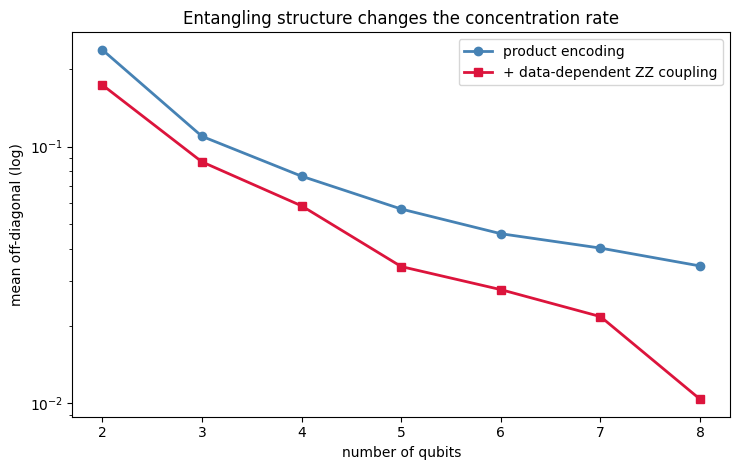

In [8]:
xs = torch.linspace(-1, 1, 8); off_mask = ~torch.eye(8, dtype=bool)
n_list = [2, 3, 4, 5, 6, 7, 8]
prod = [quantum_kernel_matrix(xs, n, 3.0, entangle=False)[off_mask].mean().item() for n in n_list]
ent  = [quantum_kernel_matrix(xs, n, 3.0, entangle=True )[off_mask].mean().item() for n in n_list]

plt.figure(figsize=(7.5, 4.8))
plt.semilogy(n_list, prod, 'o-', color='steelblue', lw=2, label='product encoding')
plt.semilogy(n_list, ent,  's-', color='crimson',   lw=2, label='+ data-dependent ZZ coupling')
plt.xlabel('number of qubits'); plt.ylabel('mean off-diagonal (log)')
plt.title('Entangling structure changes the concentration rate')
plt.legend(); plt.tight_layout(); plt.show()

**Enhancement — is the quantum kernel actually any good? (exercise 2).** We pit quantum-kernel KRR against
a tuned RBF on the same `sin(4x)` target. The honest answer mirrors Lesson 04: a well-tuned classical kernel is
a *strong* baseline. At the right bandwidth the quantum kernel **ties** it here — and at the wrong bandwidth it
loses badly. Quantum is not automatically better; it must produce a `K` whose structure beats the classical
one, which is the entire research bet behind QEK.

quantum kernel scale=1.0: test MSE 0.0007
quantum kernel scale=4.0: test MSE 0.1313
tuned RBF: test MSE 0.0006


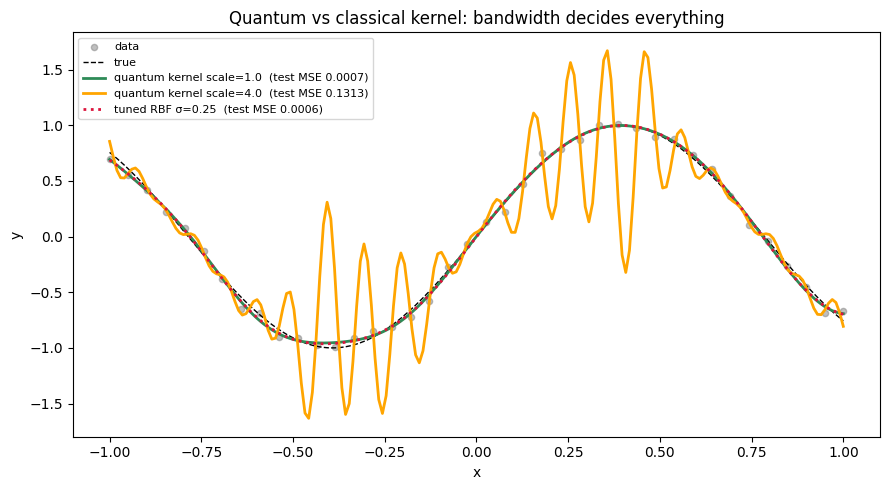

In [9]:
torch.manual_seed(0)
xtr = torch.linspace(-1, 1, 40); ytr = torch.sin(4 * xtr) + 0.05 * torch.randn(40)
xte = torch.linspace(-1, 1, 200); yte_true = torch.sin(4 * xte)

def krr_fit_predict(K_tr, K_te, y, lam=1e-3):
    a = torch.linalg.solve(K_tr + lam * torch.eye(len(y)), y)
    return K_te @ a

def qk_test_block(xtr, xte, nq, sc):
    sa = [feature_state(float(x), nq, sc) for x in xtr]
    sb = [feature_state(float(x), nq, sc) for x in xte]
    Kt = torch.zeros(len(xte), len(xtr))
    for i in range(len(xte)):
        for j in range(len(xtr)):
            ov = torch.vdot(sb[i], sa[j]); Kt[i, j] = (ov.conj() * ov).real
    return Kt

def rbf(A, B, sigma):
    return torch.exp(-(torch.cdist(A.unsqueeze(1), B.unsqueeze(1)) ** 2) / (2 * sigma ** 2))

plt.figure(figsize=(9, 5))
plt.scatter(xtr, ytr, s=20, c='gray', alpha=0.5, label='data')
plt.plot(xte, yte_true, 'k--', lw=1, label='true')

# quantum at a good scale and a bad scale
for sc, col in [(1.0, 'seagreen'), (4.0, 'orange')]:
    yq = krr_fit_predict(quantum_kernel_matrix(xtr, 5, sc), qk_test_block(xtr, xte, 5, sc), ytr)
    mse = (yq - yte_true).pow(2).mean().item()
    plt.plot(xte, yq, color=col, lw=2, label=f'quantum kernel scale={sc}  (test MSE {mse:.4f})')
    print(f'quantum kernel scale={sc}: test MSE {mse:.4f}')

yr = krr_fit_predict(rbf(xtr, xtr, 0.25), rbf(xte, xtr, 0.25), ytr)
mse_r = (yr - yte_true).pow(2).mean().item()
plt.plot(xte, yr, color='crimson', lw=2, ls=':', label=f'tuned RBF σ=0.25  (test MSE {mse_r:.4f})')
print(f'tuned RBF: test MSE {mse_r:.4f}')
plt.title('Quantum vs classical kernel: bandwidth decides everything')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. The real thing: Pasqal's QEK

The toy `feature_state` above stands in for what QEK does *physically*: encode a **graph** (Lesson 04) into a
Rydberg Hamiltonian, evolve it, and turn the measured distribution into a kernel value. Then SVM/KRR (Lesson 03)
finish the job — the pipeline Pasqal used for molecular-toxicity prediction on neutral-atom hardware.

```
This notebook (simulated):  x ─► kron-encoded state |ψ(x)⟩ ─► |⟨ψ|ψ⟩|² ─► K ─► KRR/SVM
Pasqal QEK (hardware):      graph ─► Rydberg Hamiltonian ─► evolve + measure ─► K ─► KRR/SVM
```

*References:* `arXiv:2107.03247` (QEK), `arXiv:2501.07433` (concentration ↔ barren plateaus),
`arXiv:2508.10819` (blockade-regime kernels), `arXiv:2509.14337` (symmetry-structured trainable kernels).

---
# Lesson 07 — Neural Networks & Classification

A variational quantum circuit is *structurally* a neural network: parameterized layers, a nonlinearity
(measurement), a loss, gradient training. Getting fluent with `nn.Module` + cross-entropy transfers straight to
hybrid quantum-classical models (Lesson 12).

## 1. Why layers need activations

A stack of linear layers with **no** nonlinearity collapses to a single linear layer — no added power. The
**activation** (ReLU, tanh) is what lets a network bend its decision boundary. We'll *prove* the collapse
numerically, then see it visually on a non-separable dataset in §3.

In [10]:
torch.manual_seed(0)
a, b = nn.Linear(2, 8), nn.Linear(8, 2)
x = torch.randn(5, 2)

# composition of two linears is itself affine: W_eff = b.W @ a.W,  bias_eff = b.W @ a.b + b.b
W_eff = b.weight @ a.weight
b_eff = b.weight @ a.bias + b.bias
print("two stacked Linears == one affine map:",
      torch.allclose(b(a(x)), x @ W_eff.T + b_eff, atol=1e-6))
print("-> without an activation between them, depth buys nothing.")

two stacked Linears == one affine map: True
-> without an activation between them, depth buys nothing.


## 2. A multi-class classifier (with decision regions)

The standard recipe: `linear → activation → linear → logits`, trained with cross-entropy (which folds in
softmax). We classify three Gaussian blobs — and, as an **enhancement over the study guide**, plot the full
learned decision regions, not just the accuracy number.

epoch   0  loss 1.157  acc 56.33%
epoch 100  loss 0.000  acc 100.00%
epoch 200  loss 0.000  acc 100.00%
final train accuracy: 1.0


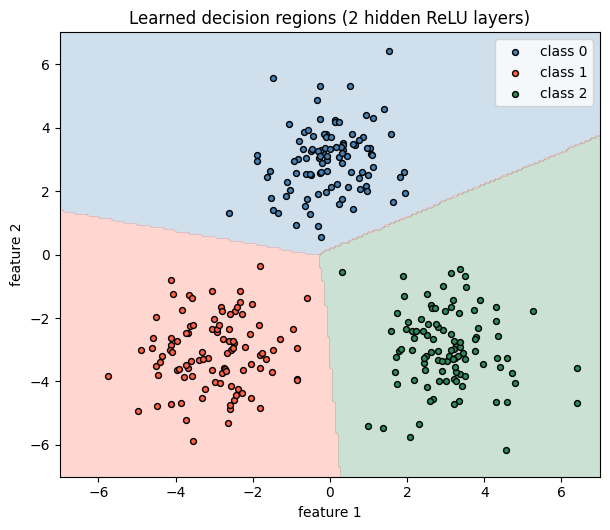

In [11]:
torch.manual_seed(0)
def blobs(n, center): return torch.randn(n, 2) + torch.tensor(center)
X = torch.cat([blobs(100, [0, 3]), blobs(100, [-3, -3]), blobs(100, [3, -3])])
y = torch.cat([torch.zeros(100), torch.ones(100), 2 * torch.ones(100)]).long()

model = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 3))
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()                       # expects raw logits + integer labels
for epoch in range(300):
    opt.zero_grad(); loss = loss_fn(model(X), y); loss.backward(); opt.step()
    if epoch % 100 == 0:
        acc = (model(X).argmax(1) == y).float().mean()
        print(f"epoch {epoch:3d}  loss {loss.item():.3f}  acc {acc.item():.2%}")
print("final train accuracy:", round((model(X).argmax(1) == y).float().mean().item(), 3))

# decision regions
gx = torch.linspace(-7, 7, 200)
G1, G2 = torch.meshgrid(gx, gx, indexing='xy')
grid = torch.stack([G1.reshape(-1), G2.reshape(-1)], dim=1)
with torch.no_grad():
    Z = model(grid).argmax(1).reshape(G1.shape)
plt.figure(figsize=(6.2, 5.4))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=['steelblue', 'tomato', 'seagreen'], alpha=0.25)
for cls, col in zip([0, 1, 2], ['steelblue', 'tomato', 'seagreen']):
    plt.scatter(X[y == cls, 0], X[y == cls, 1], c=col, edgecolor='k', s=18, label=f'class {cls}')
plt.title('Learned decision regions (2 hidden ReLU layers)')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.legend()
plt.tight_layout(); plt.show()

## 3. Activations matter — and a train/validation split

Two points at once. **(a)** On **concentric circles** — a dataset *no* straight line can split — a network with
**no activation** is stuck near chance (~42%), while ReLU/Tanh wrap around the inner ring and reach ~97%
(exercises 1 & 2). **(b)** We judge each model on a **held-out validation split** (Lesson 05), never on
training data.

 no activation: validation accuracy 50.00%
          ReLU: validation accuracy 95.00%
          Tanh: validation accuracy 95.00%


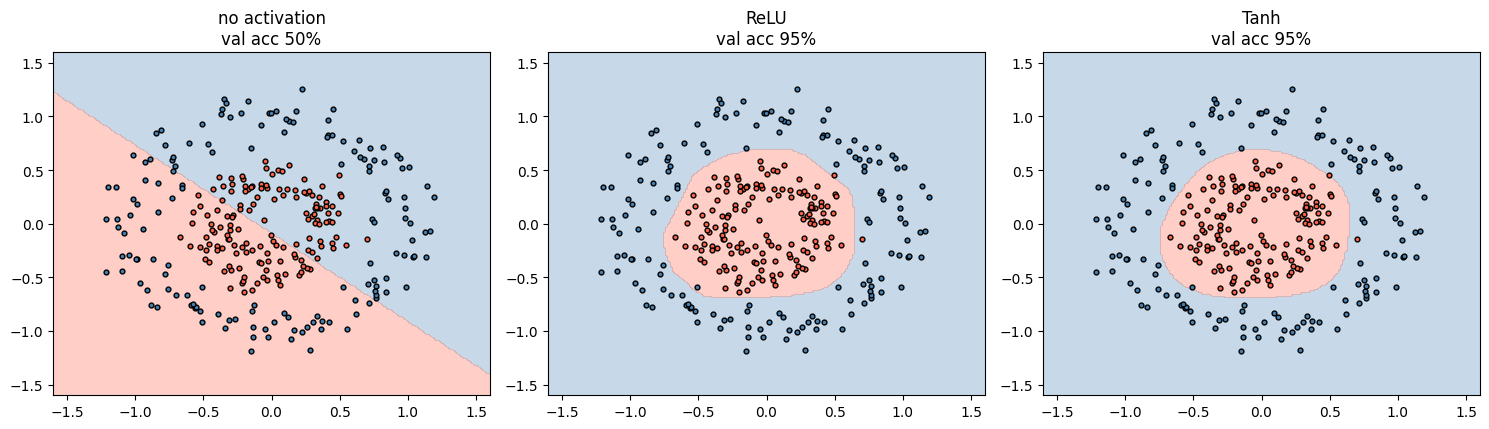

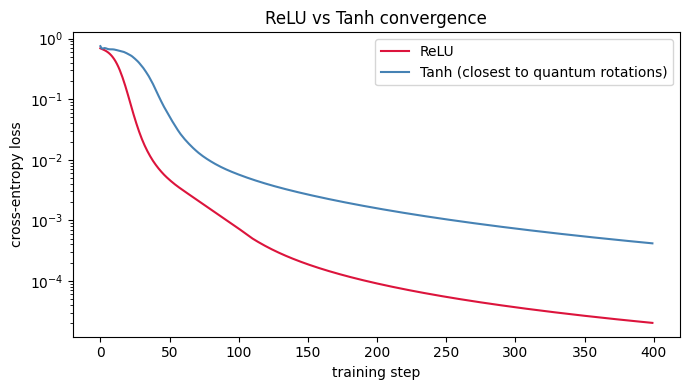

In [12]:
Xm_np, ym_np = make_circles(300, noise=0.12, factor=0.4, random_state=0)
Xm = torch.tensor(Xm_np, dtype=torch.float); ym = torch.tensor(ym_np)
perm = torch.randperm(300); tr, va = perm[:240], perm[240:]      # 80/20 split

def train_net(act, n_steps=400):
    torch.manual_seed(1)
    layers = [nn.Linear(2, 32)]
    if act is not None: layers.append(act())
    layers += [nn.Linear(32, 32)]
    if act is not None: layers.append(act())
    layers += [nn.Linear(32, 2)]
    net = nn.Sequential(*layers)
    opt = torch.optim.Adam(net.parameters(), lr=0.01); lf = nn.CrossEntropyLoss()
    losses = []
    for _ in range(n_steps):
        opt.zero_grad(); l = lf(net(Xm[tr]), ym[tr]); l.backward(); opt.step(); losses.append(l.item())
    return net, losses

configs = [('no activation', None), ('ReLU', nn.ReLU), ('Tanh', nn.Tanh)]
gx = torch.linspace(-1.6, 1.6, 200); G1, G2 = torch.meshgrid(gx, gx, indexing='xy')
grid = torch.stack([G1.reshape(-1), G2.reshape(-1)], dim=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
loss_curves = {}
for ax, (name, act) in zip(axes, configs):
    net, losses = train_net(act); loss_curves[name] = losses
    with torch.no_grad():
        Z = net(grid).argmax(1).reshape(G1.shape)
        val_acc = (net(Xm[va]).argmax(1) == ym[va]).float().mean().item()
    ax.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5], colors=['steelblue', 'tomato'], alpha=0.3)
    ax.scatter(Xm[ym == 0, 0], Xm[ym == 0, 1], c='steelblue', edgecolor='k', s=12)
    ax.scatter(Xm[ym == 1, 0], Xm[ym == 1, 1], c='tomato', edgecolor='k', s=12)
    ax.set_title(f'{name}\nval acc {val_acc:.0%}')
    print(f'{name:>14}: validation accuracy {val_acc:.2%}')
plt.tight_layout(); plt.show()

# convergence comparison (exercise 2): ReLU vs Tanh
plt.figure(figsize=(7, 4))
plt.plot(loss_curves['ReLU'], color='crimson', label='ReLU')
plt.plot(loss_curves['Tanh'], color='steelblue', label='Tanh (closest to quantum rotations)')
plt.xlabel('training step'); plt.ylabel('cross-entropy loss'); plt.yscale('log')
plt.title('ReLU vs Tanh convergence'); plt.legend(); plt.tight_layout(); plt.show()

## 4. The bridge to variational quantum models

| Neural network | Variational quantum circuit |
|----------------|-----------------------------|
| Input features `x` | Data-encoding gates (feature map) |
| Trainable weights `W, b` | Trainable rotation angles `θ` |
| ReLU / tanh nonlinearity | Measurement (Born rule) |
| Stacked layers | Alternating encode / entangle layers |
| Softmax + cross-entropy | Measurement probabilities + loss |
| Backprop | Autodiff / **parameter-shift** (Lesson 09) |
| Data re-input (rare) | **Data re-uploading** (common, boosts expressivity) |

The training loop is *identical* — which is exactly why Qadence makes a quantum model a drop-in `nn.Module`.

---
# Lesson 08 — Probabilistic & Generative Modeling

Measurement on a quantum device *is* sampling from a probability distribution defined by the state. A **Born
machine** trains a parameterized circuit so its measurement distribution matches data — pure generative
modeling. The losses (NLL, KL, MMD) and the *think-in-samples* mindset here are exactly what you use there.

## 1. Distributions and sampling

A generative model is a distribution you can sample from. Measurement on `n` qubits is a categorical over `2ⁿ`
bitstrings (the Born rule, Lesson 06).

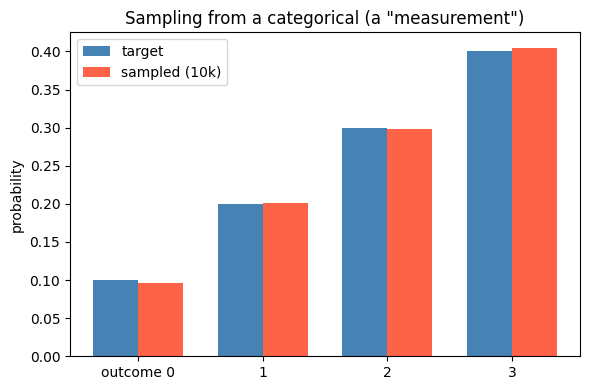

target : [0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]
sampled: [0.09600000083446503, 0.20100000500679016, 0.2980000078678131, 0.4050000011920929]


In [13]:
torch.manual_seed(0)
probs = torch.tensor([0.1, 0.2, 0.3, 0.4])
samples = torch.multinomial(probs, num_samples=10000, replacement=True)
empirical = torch.bincount(samples, minlength=4).float() / 10000

xb = np.arange(4)
plt.figure(figsize=(6, 4))
plt.bar(xb - 0.18, probs.numpy(), width=0.36, color='steelblue', label='target')
plt.bar(xb + 0.18, empirical.numpy(), width=0.36, color='tomato', label='sampled (10k)')
plt.xticks(xb, ['outcome 0', '1', '2', '3']); plt.ylabel('probability')
plt.title('Sampling from a categorical (a "measurement")'); plt.legend()
plt.tight_layout(); plt.show()
print("target :", probs.tolist())
print("sampled:", empirical.round(decimals=3).tolist())

## 2. Maximum likelihood = minimizing negative log-likelihood

Fitting a model means making the observed data probable under it. For a categorical, MLE matches empirical
frequencies, and the loss is the **negative log-likelihood** — the same quantity inside cross-entropy
(Lesson 07). A Born machine trains the *same way*; only the source of the probabilities changes (a circuit's
measurement statistics instead of a softmax).

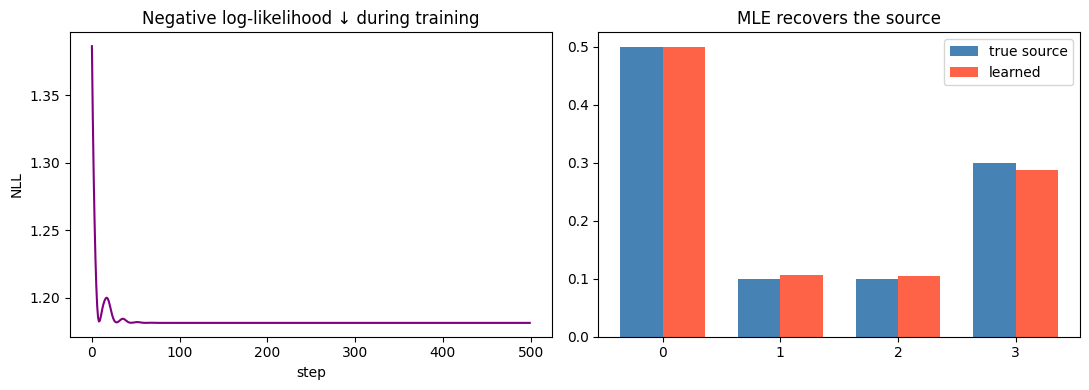

learned probs: [0.5, 0.10700000077486038, 0.10599999874830246, 0.28700000047683716]  (true: [0.5, 0.1, 0.1, 0.3])


In [14]:
torch.manual_seed(0)
data = torch.multinomial(torch.tensor([0.5, 0.1, 0.1, 0.3]), 2000, replacement=True)

logits = torch.zeros(4, requires_grad=True)
opt = torch.optim.Adam([logits], lr=0.1)
nll_curve = []
for _ in range(500):
    opt.zero_grad()
    nll = -torch.log_softmax(logits, dim=0)[data].mean()
    nll.backward(); opt.step(); nll_curve.append(nll.item())
learned = torch.softmax(logits, 0).detach()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(nll_curve, color='purple'); ax1.set_xlabel('step'); ax1.set_ylabel('NLL')
ax1.set_title('Negative log-likelihood ↓ during training')
xb = np.arange(4)
ax2.bar(xb - 0.18, [0.5, 0.1, 0.1, 0.3], width=0.36, color='steelblue', label='true source')
ax2.bar(xb + 0.18, learned.numpy(), width=0.36, color='tomato', label='learned')
ax2.set_xticks(xb); ax2.set_title('MLE recovers the source'); ax2.legend()
plt.tight_layout(); plt.show()
print("learned probs:", learned.round(decimals=3).tolist(), " (true: [0.5, 0.1, 0.1, 0.3])")

## 3. KL divergence — and its asymmetry

`KL(p‖q)` measures the cost of using `q` to model true `p`. It's zero only when the distributions match, and it
is **asymmetric** — `KL(p‖q) ≠ KL(q‖p)` — a fact that matters when choosing a generative loss (exercise 1).

KL(p||close)   = 0.0121
KL(p||uniform) = 0.2180   (larger)
KL(p||p)       = 0.0000   (~0)
asymmetry:  KL(p||uniform) = 0.2180  vs  KL(uniform||p) = 0.2393


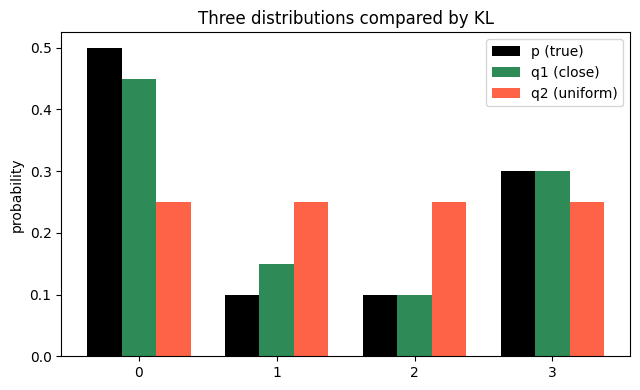

In [15]:
def kl(p, q, eps=1e-12):
    p = p + eps; q = q + eps
    return (p * (p / q).log()).sum()

p  = torch.tensor([0.5, 0.1, 0.1, 0.3])
q1 = torch.tensor([0.45, 0.15, 0.1, 0.3])      # close to p
q2 = torch.tensor([0.25, 0.25, 0.25, 0.25])    # uniform, far from p

print(f"KL(p||close)   = {kl(p, q1).item():.4f}")
print(f"KL(p||uniform) = {kl(p, q2).item():.4f}   (larger)")
print(f"KL(p||p)       = {kl(p, p).item():.4f}   (~0)")
print(f"asymmetry:  KL(p||uniform) = {kl(p, q2).item():.4f}  vs  KL(uniform||p) = {kl(q2, p).item():.4f}")

xb = np.arange(4)
plt.figure(figsize=(6.5, 4))
plt.bar(xb - 0.25, p.numpy(),  width=0.25, color='black',     label='p (true)')
plt.bar(xb,        q1.numpy(), width=0.25, color='seagreen',  label='q1 (close)')
plt.bar(xb + 0.25, q2.numpy(), width=0.25, color='tomato',    label='q2 (uniform)')
plt.xticks(xb); plt.ylabel('probability'); plt.title('Three distributions compared by KL'); plt.legend()
plt.tight_layout(); plt.show()

## 4. A minimal generative model trained by MMD

To generate *continuous* data, learn a map from a simple base (Gaussian) to the data. We train it with **MMD**
(maximum mean discrepancy) — a kernel-based distribution distance that *reuses the RBF kernel from Lesson 02*
and needs only **samples**. That sample-only property is precisely why quantum generative models favour MMD: a
quantum device gives you samples, not densities.

**Enhancement:** the study guide only printed the mean/std; here we overlay the histograms to confirm the
generator recovers the **bimodal** shape.

generated mean 0.07  std 1.50  (target ~mean 0, std ~1.55)


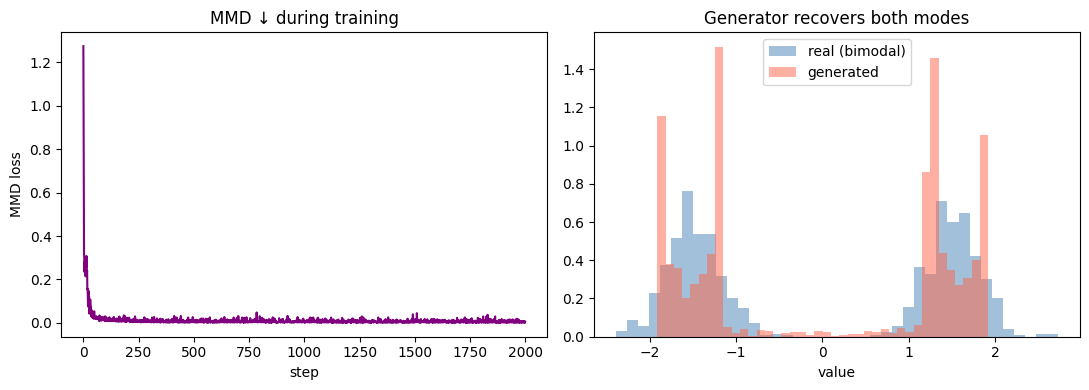

In [16]:
torch.manual_seed(0)
data = torch.cat([torch.randn(500) * 0.3 + 1.5, torch.randn(500) * 0.3 - 1.5]).unsqueeze(1)  # bimodal

gen = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
opt = torch.optim.Adam(gen.parameters(), lr=0.01)

def mmd(a, b, sigma=0.5):
    def k(x, y): return torch.exp(-(torch.cdist(x, y) ** 2) / (2 * sigma ** 2))
    return k(a, a).mean() + k(b, b).mean() - 2 * k(a, b).mean()

mmd_curve = []
for step in range(2000):
    z = torch.randn(256, 1)
    real = data[torch.randint(0, len(data), (256,))]
    opt.zero_grad(); loss = mmd(gen(z), real); loss.backward(); opt.step(); mmd_curve.append(loss.item())

with torch.no_grad():
    fake = gen(torch.randn(2000, 1)).squeeze()
print(f"generated mean {fake.mean():.2f}  std {fake.std():.2f}  (target ~mean 0, std ~1.55)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(mmd_curve, color='purple'); ax1.set_xlabel('step'); ax1.set_ylabel('MMD loss')
ax1.set_title('MMD ↓ during training')
ax2.hist(data.squeeze().numpy(), bins=40, density=True, alpha=0.5, color='steelblue', label='real (bimodal)')
ax2.hist(fake.numpy(), bins=40, density=True, alpha=0.5, color='tomato', label='generated')
ax2.set_title('Generator recovers both modes'); ax2.set_xlabel('value'); ax2.legend()
plt.tight_layout(); plt.show()

## 5. Enhancement — a categorical Born-machine simulation (exercise 3)

Make the base distribution categorical over `2ⁿ` bitstrings and train it to match a target by NLL. This is a
**direct classical simulation of a Born machine**: replace the softmax-over-bitstrings with a real circuit's
measurement statistics and you have the quantum version, trained by the identical objective.

final KL(target || learned) = 0.0003


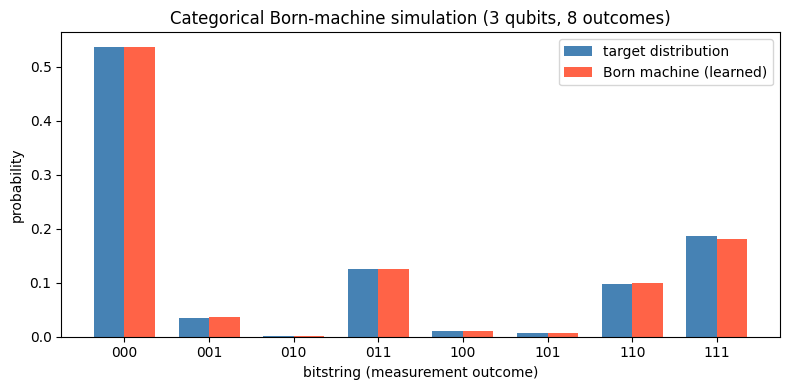

In [17]:
torch.manual_seed(0)
n_qubits = 3; dim = 2 ** n_qubits
target = torch.softmax(torch.randn(dim) * 1.5, 0)                  # the distribution to learn
target_samples = torch.multinomial(target, 4000, replacement=True)  # all we "measure"

bm_logits = torch.zeros(dim, requires_grad=True)
opt = torch.optim.Adam([bm_logits], lr=0.1)
for _ in range(800):
    opt.zero_grad()
    nll = -torch.log_softmax(bm_logits, 0)[target_samples].mean()
    nll.backward(); opt.step()
learned = torch.softmax(bm_logits, 0).detach()
print(f"final KL(target || learned) = {kl(target, learned).item():.4f}")

xb = np.arange(dim)
labels = [format(i, f'0{n_qubits}b') for i in range(dim)]
plt.figure(figsize=(8, 4))
plt.bar(xb - 0.18, target.numpy(),  width=0.36, color='steelblue', label='target distribution')
plt.bar(xb + 0.18, learned.numpy(), width=0.36, color='tomato',    label='Born machine (learned)')
plt.xticks(xb, labels); plt.xlabel('bitstring (measurement outcome)'); plt.ylabel('probability')
plt.title(f'Categorical Born-machine simulation ({n_qubits} qubits, {dim} outcomes)')
plt.legend(); plt.tight_layout(); plt.show()

## The bridge to quantum generative models

| Classical generative model | Quantum (Born machine / DQGM) |
|----------------------------|-------------------------------|
| Sample from softmax / flow | Sample from measurement (Born rule) |
| NLL / KL / **MMD** loss | Same losses (MMD especially — sample-only) |
| Neural-net generator | Parameterized quantum circuit |
| Backprop | Autodiff / parameter-shift (Lesson 09) |

Neutral-atom hardware is a natural sampler, so generative modeling is a leading near-term QML application. The
transferable skill is thinking in **distributions and samples**, not closed-form densities.

---

### Where the whole arc stands now

- **Lessons 02–06** built the *kernel* path that culminates in QEK: feature map → Gram matrix → KRR/SVM, with
  concentration as the central hazard.
- **Lesson 07** showed the *variational* path: a quantum circuit is a neural network with measurement as its
  nonlinearity.
- **Lesson 08** showed the *generative* path: measurement is sampling, trained by NLL/KL/MMD.

**Next:** Lesson 09 makes the variational circuit real (parameter-shift gradients), Lesson 10 fights
concentration/barren plateaus with geometry & symmetry, and Lesson 12 stitches it all into a hybrid pipeline.